In [4]:
import confnotebook

In [5]:
from pathlib import Path

source = Path("../examples/test/bag_15062026")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 000-591590 2024 Р±РЅ
[1] 000-591590 2025 Р±РЅ
[2] 000-591590 2026 Р±РЅ
[3] 04062001scan
[4] 1 квартал 2026
[5] 113130_Черно-бел. док-т_04062026
[6] 20260604scan150446
[7] 3 кв. 2025
[8] Scan_0034
[9] scan_20010116015111
[10] Акт сверки 01012026-31032026
[11] Акт сверки 2025 от 16.04.2026 (1)
[12] акт сверки 2025
[13] Акт сверки 2026 от 16.04.2026
[14] Акт сверки взаиморасчетов № 05800004074 от 29 мая 2026 г
[15] Акт сверки взаиморасчетов № 102 от 03 июня 2026 г
[16] Акт сверки взаиморасчетов № 151 от 20 мая 2026 г без 9_10 этапа
[17] Акт сверки взаиморасчетов № 6171 от 02 июня 2026 г
[18] Акт сверки май 2026
[19] Акт Сверки РУСАЛ Ачинск
[20] Акт сверки янв-мар 2026 (подпись К-ПМ)
[21] Акт сверки №1523 от 21.04.26 - 5f1bfca4-fde6-48ac-93cd-9266c8fa14d2
[22] Акт сверки №И--000238 от 06.04.26 РИТС
[23] Акт сверки
[24] Альфа-Металл
[25] АС АО КУРГАНМАШЗАВОД
[26] АС РБ за 2025 г
[27] ас скс 1кв 2026
[28] АС СУЭК апрель 26
[29] АСВ Лоста на 31.03.
[30] Байкал Аква 23-26
[31] БАЙКАЛ АКВА 

In [6]:
IDX_FILE = 0

In [7]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=0, dpi=200)

img, _ = PageOrientationPreprocessor().process(img)


d:\projects\rusal_recon_srv\repo\recon_vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
d:\projects\rusal_recon_srv\repo\recon_vision\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
2026-06-15 15:29:13.241 | DEBUG    | vision_core.preprocessor.image_orientation:process:47 - Ориентация страницы: 0° с точностью 0.9194
2026-06-15 15:29:13.439 | DEBUG    | vision_core.preprocessor.image_orientation:compute_deskew_angle:11

In [8]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 30))
# plt.imshow(img)
# plt.title("original image")
# plt.show()

In [9]:
import cv2
import numpy as np

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

# # 3 images visualization
# plt.figure(figsize=(20, 30))
# plt.subplot(1, 3, 1)
# plt.imshow(l, cmap='gray')
# plt.title("lightness")
# plt.subplot(1, 3, 2)
# plt.imshow(a, cmap='gray')
# plt.title("a channel")
# plt.subplot(1, 3, 3)
# plt.imshow(b, cmap='gray')
# plt.title("b channel")
# plt.show()

In [10]:
blur = cv2.GaussianBlur(l, (1, 1), 0)
gamma = 10.0
lut = (np.arange(256) / 255) ** gamma * 255
gamma_img = cv2.LUT(blur, lut.astype(np.uint8))


# plt.figure(figsize=(20, 30))
# plt.imshow(gamma_img, cmap='gray')
# plt.title("gamma corrected lightness channel")
# plt.show()

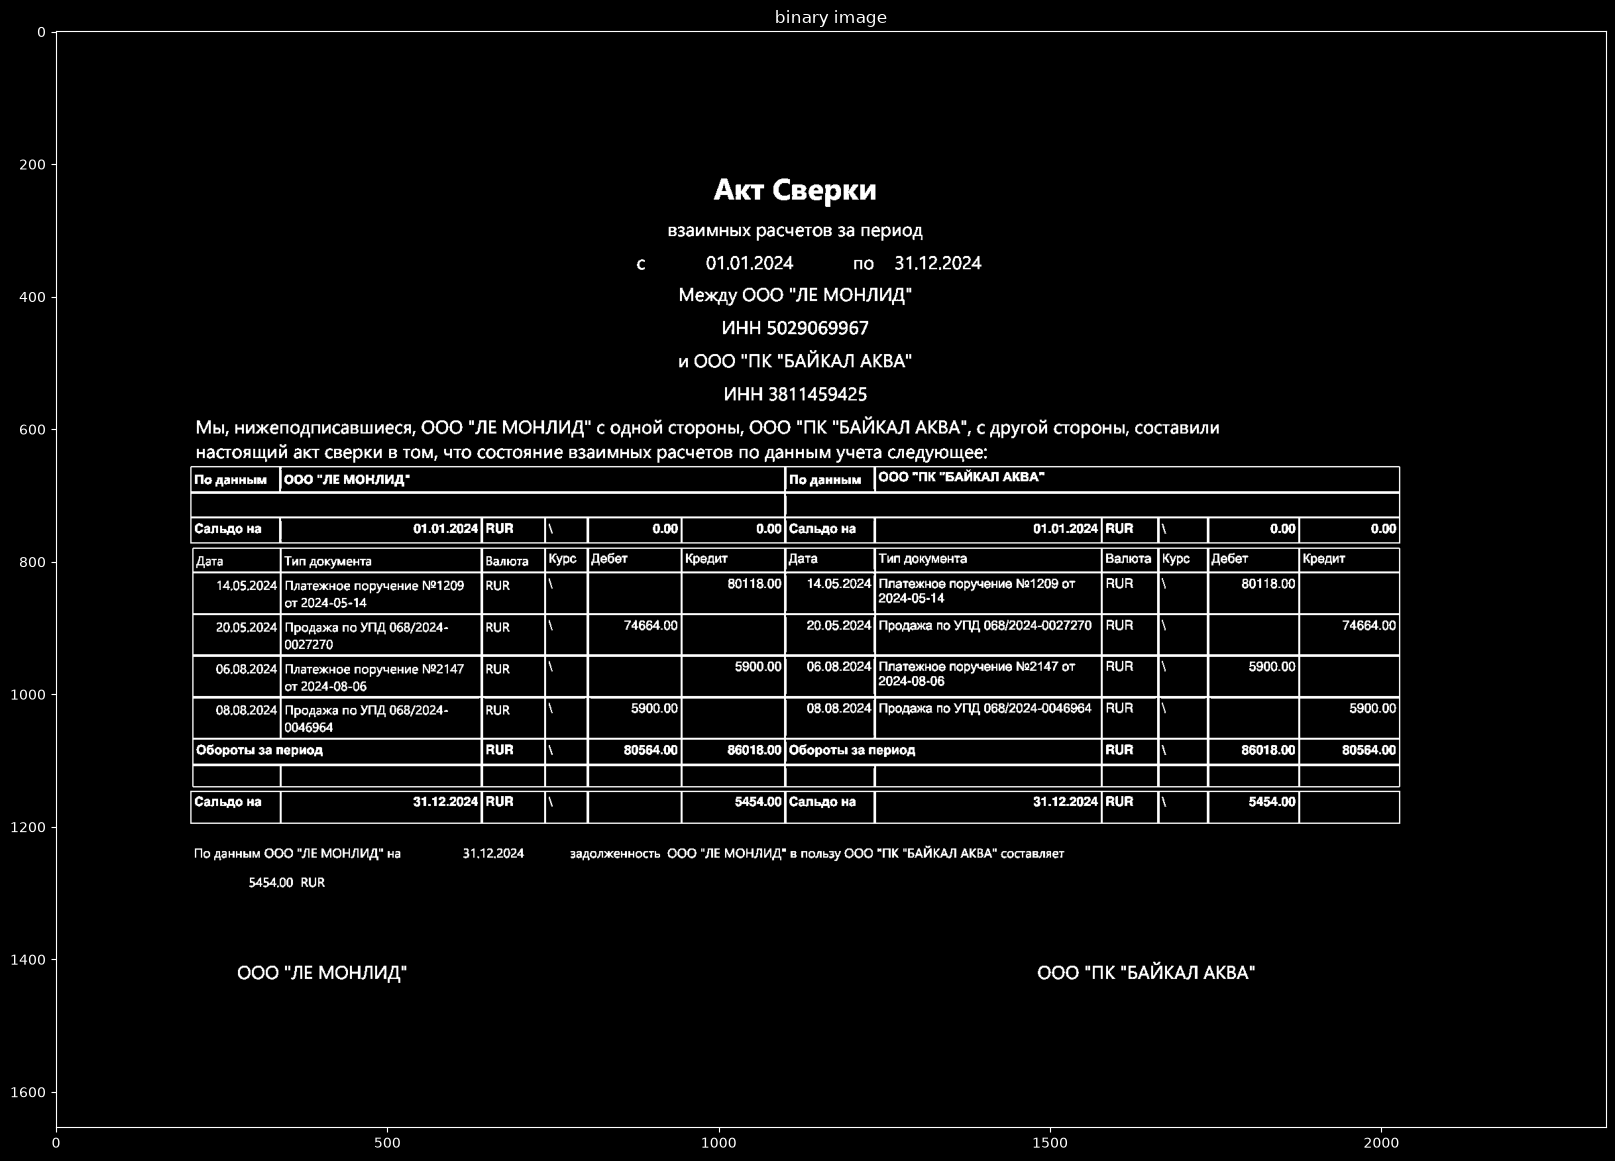

In [11]:
bin_img = cv2.adaptiveThreshold(gamma_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 11, 5)
bin_img = cv2.dilate(bin_img, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1)), iterations=1)
plt.figure(figsize=(20, 30))
plt.imshow(bin_img, cmap='gray')
plt.title("binary image")
plt.show()

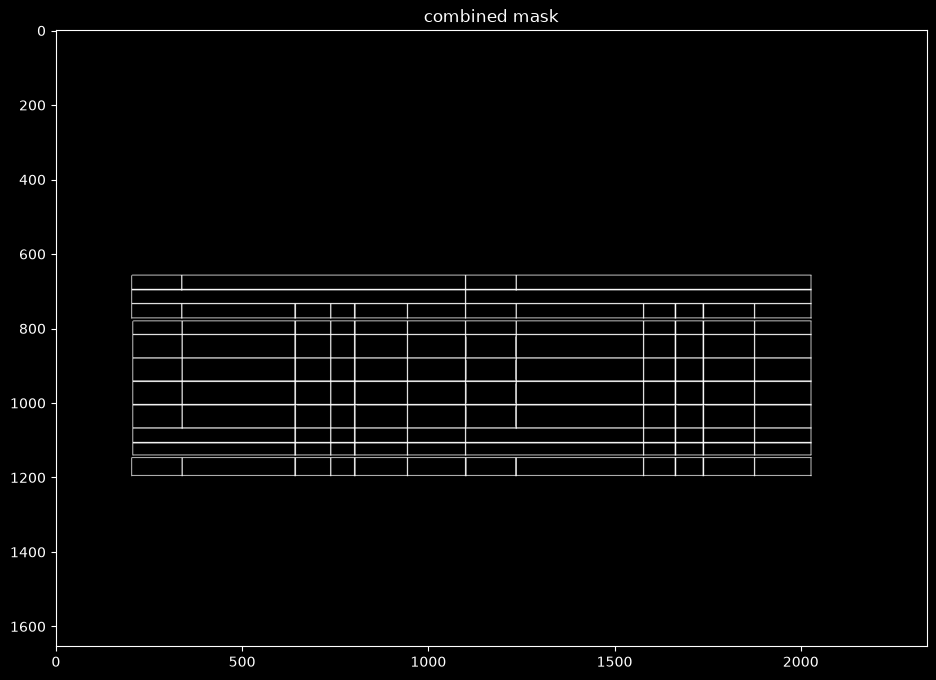

In [12]:
from vision_core.utils.image_utils import compute_horizontal_line_mask, compute_vertical_line_mask, get_mask

h_mask = compute_horizontal_line_mask(bin_img, scale=40)
v_mask = compute_vertical_line_mask(bin_img, median_height=40)
mask = get_mask(h_mask, v_mask)
plt.figure(figsize=(20, 8))
plt.imshow(mask, cmap='gray')
plt.title("combined mask")
plt.show()

Found contour at (203, 1146, 1827, 51)
Contour at (203, 1146, 1827, 51), density: 0.1001, touches border: False
Found contour at (206, 779, 1824, 363)
Contour at (206, 779, 1824, 363), density: 0.0898, touches border: False
Found contour at (203, 656, 1827, 118)
Contour at (203, 656, 1827, 118), density: 0.1035, touches border: False
[BBox(x_min=203.0, y_min=1146.0, x_max=2030.0, y_max=1197.0), BBox(x_min=206.0, y_min=779.0, x_max=2030.0, y_max=1142.0), BBox(x_min=203.0, y_min=656.0, x_max=2030.0, y_max=774.0)]


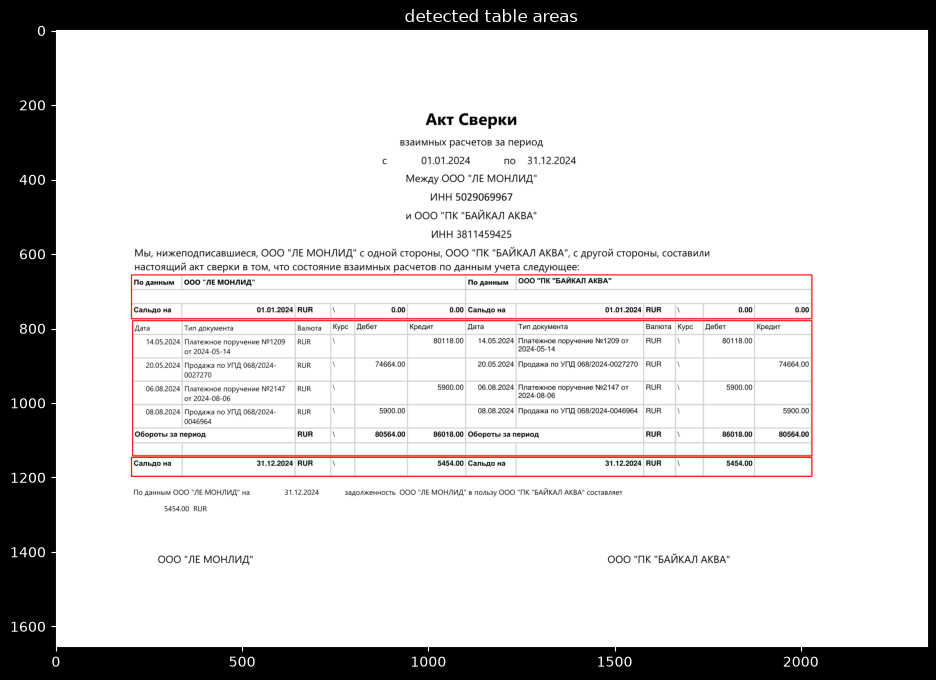

In [13]:
from vision_core.entities.bbox import BBox

img_with_boxes = img.copy()

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

candidates: list[BBox] = []
H, W = mask.shape[:2]
border_tol = 8
min_width = int(W * 0.35)
# min_height = int(H * 0.08)
min_density = 0.01

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    print(f"Found contour at ({x}, {y}, {w}, {h})")
    
    if w < min_width or h < 20:
        continue

    if w > W * 0.95 and h > H * 0.95:
        continue

    # рамка страницы/паразитный контур
    touches_border = (
        x <= border_tol or y <= border_tol or
        x + w >= W - border_tol or y + h >= H - border_tol
    )
    roi = mask[y:y+h, x:x+w]
    density = cv2.countNonZero(roi) / max(1, w * h)
    print(f"Contour at ({x}, {y}, {w}, {h}), density: {density:.4f}, touches border: {touches_border}")
    if touches_border and density < min_density:
        continue

    bbox = BBox(x_min=x, y_min=y, x_max=x + w, y_max=y + h)
    candidates.append(bbox)

bboxes = []
for box in candidates:
    if any(
        kept.contains(box) or box.contains(kept) 
        or kept.intersection_over_min(box) > 0.3
        for kept in bboxes
    ):
        continue
    bboxes.append(box)
# bboxes = sorted(bboxes, key=lambda b: b.y_min)
print(bboxes)
for bbox in bboxes:
    x0, y0, x1, y1 = bbox.to_tuple()
    cv2.rectangle(img_with_boxes, (x0, y0), (x1, y1), (255, 0, 0), 2)


plt.figure(figsize=(12, 8))
plt.imshow(img_with_boxes)
plt.title('detected table areas')
plt.show()

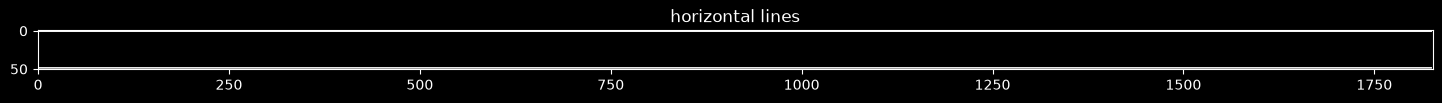

In [14]:
scale = 20

# в каждом боксе найдем горизонтальные линии
h_lines_mask = []
for bbox in bboxes:
    box_bin = bbox.roi(bin_img)
    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(box_bin.shape[1] // scale), 1))
    mask = cv2.morphologyEx(box_bin, cv2.MORPH_OPEN, horiz_kernel, iterations=2)
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1)), iterations=1)
    h_lines_mask.append(mask)

plt.figure(figsize=(18, 6))
plt.imshow(h_lines_mask[0], cmap='gray')
plt.title("horizontal lines")
plt.show()

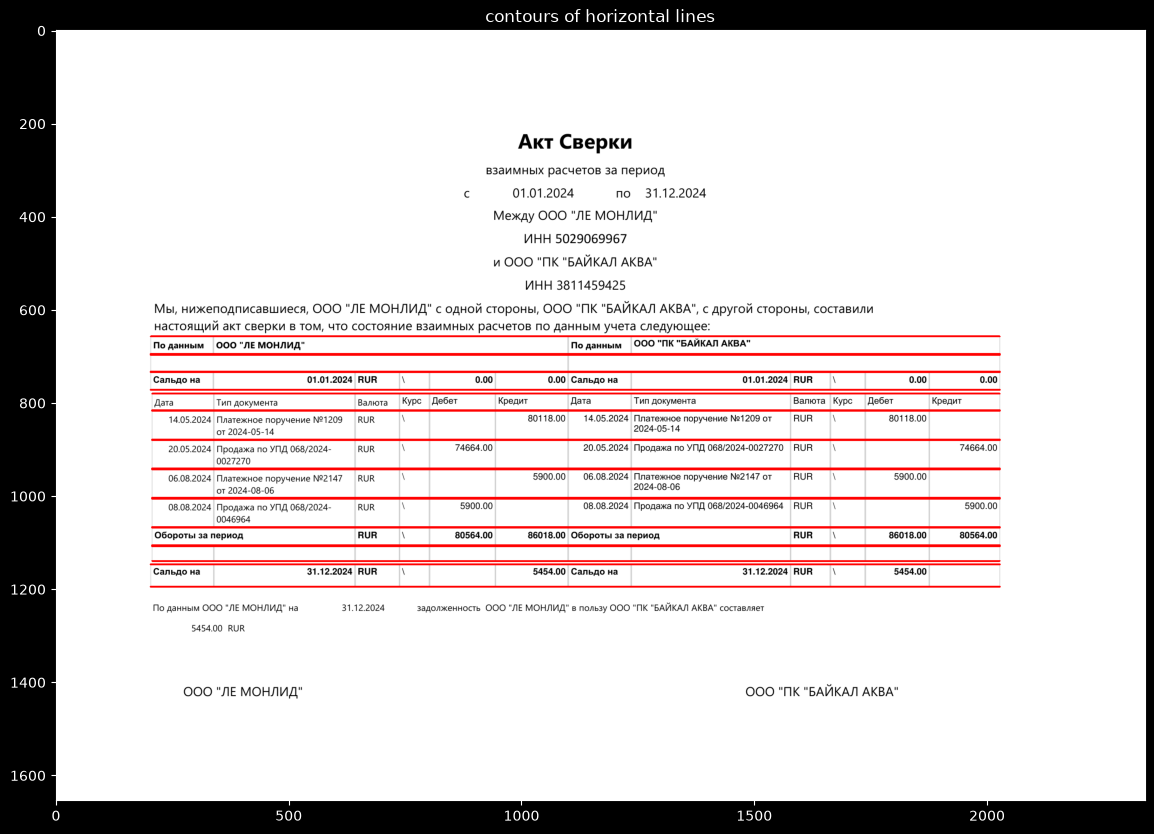

In [15]:
# найдем горизонтальные линии в каждом боксе
contour_img = img.copy()

h_raw_lines = []

for bbox, mask in zip(bboxes, h_lines_mask, strict=False):
    lines = cv2.HoughLinesP(mask, 1, np.pi / 180, threshold=15, minLineLength=bbox.width//8, maxLineGap=bbox.width//10)
    h_raw_lines.append(lines)
    x_min, y_min, x_max, y_max = bbox.to_tuple()
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(contour_img, (x1 + x_min, y1 + y_min), (x2 + x_min, y2 + y_min), (255, 0, 0), 2)

plt.figure(figsize=(20, 10))
plt.imshow(contour_img)
plt.title("contours of horizontal lines")
plt.show()

In [28]:
from enum import Enum
from typing import TypeAlias

import numpy as np
import numpy.typing as npt


class LineAxis(Enum):
    X = 0
    Y = 1

Int32Array: TypeAlias = npt.NDArray[np.int32]
SegmentsArray: TypeAlias = npt.NDArray[np.int32]

def merge_close(coords: np.ndarray, gap: int = 3) -> np.ndarray:
    coords = np.asarray(coords, dtype=np.int32)
    if coords.size == 0:
        return np.array([], dtype=np.int32)

    coords = np.sort(coords)

    # Границы новых групп там, где разница стала больше gap
    split_idx = np.flatnonzero(np.diff(coords) > gap) + 1

    # starts / ends групп (ends - exclusive)
    starts = np.r_[0, split_idx]
    ends = np.r_[split_idx, coords.size]

    # Индекс "середины" каждой группы:
    # start + (len(group)//2), полностью векторно
    mid_idx = starts + ((ends - starts) // 2)
    return coords[mid_idx]

def find_line_axes(lines: np.ndarray, axis: LineAxis, axis_tol: int = 10) -> np.ndarray:
    if lines is None or len(lines) == 0:
        return np.array([], dtype=np.int32)
    arr = np.asarray(lines).reshape(-1, 4).astype(np.int32)

    axis_ref = arr[:, axis.value]

    if axis_ref.size == 0:
        return np.array([], dtype=np.int32)

    axes = merge_close(axis_ref, gap=axis_tol)
    return axes.astype(np.int32)


def normalize_segments(
    segs: SegmentsArray,
    merge_gap: int = 2,
    min_len: int = 8,
) -> SegmentsArray:
    segs = np.asarray(segs, dtype=np.int32).reshape(-1, 2)
    if segs.size == 0:
        return np.empty((0, 2), dtype=np.int32)

    starts = np.minimum(segs[:, 0], segs[:, 1])
    ends = np.maximum(segs[:, 0], segs[:, 1])
    segs = np.column_stack((starts, ends))

    segs = segs[segs[:, 1] > segs[:, 0]]
    if segs.size == 0:
        return np.empty((0, 2), dtype=np.int32)

    segs = np.unique(segs, axis=0)
    segs = segs[np.argsort(segs[:, 0], kind="stable")]

    merged = [segs[0].copy()]
    for s, e in segs[1:]:
        ps, pe = merged[-1]
        if s <= pe + merge_gap:
            merged[-1][1] = max(pe, e)
        else:
            merged.append(np.array([s, e], dtype=np.int32))

    out = np.vstack(merged)
    out = out[(out[:, 1] - out[:, 0]) >= min_len]
    return out.astype(np.int32, copy=False)

def collect_axis_segments(
    lines: Int32Array,
    axis_value: int,
    axis: LineAxis,
    axis_tol: int = 10,
    merge_gap: int = 5,
    min_len: int = 10,
) -> SegmentsArray:
    arr = np.asarray(lines, dtype=np.int32).reshape(-1, 4)
    if arr.size == 0:
        return np.empty((0, 2), dtype=np.int32)

    if axis is LineAxis.Y:
        # Горизонтальные линии: группируем по Y, сегменты по X.
        axis_ref = arr[:, 1]
        seg_start = np.minimum(arr[:, 0], arr[:, 2])
        seg_end = np.maximum(arr[:, 0], arr[:, 2])
    else:
        # Вертикальные линии: группируем по X, сегменты по Y.
        axis_ref = arr[:, 0]
        seg_start = np.minimum(arr[:, 1], arr[:, 3])
        seg_end = np.maximum(arr[:, 1], arr[:, 3])

    mask = np.abs(axis_ref - np.int32(axis_value)) <= np.int32(axis_tol)
    if not np.any(mask):
        return np.empty((0, 2), dtype=np.int32)

    raw_segments: SegmentsArray = np.column_stack((seg_start[mask], seg_end[mask])).astype(np.int32, copy=False)
    return normalize_segments(raw_segments, merge_gap=merge_gap, min_len=min_len)

def extract_lines(
    lines: Int32Array | None,
    axis: LineAxis,
    axis_tol: int = 10,
    merge_gap: int = 5,
    min_len: int = 10,
) -> list[tuple[int, SegmentsArray]]:
    if lines is None:
        return []

    arr = np.asarray(lines, dtype=np.int32).reshape(-1, 4)
    if arr.size == 0:
        return []

    axis_values = find_line_axes(arr, axis=axis, axis_tol=axis_tol)

    out: list[tuple[int, SegmentsArray]] = []
    for axis_value in axis_values:
        segs = collect_axis_segments(
            arr,
            axis_value=int(axis_value),
            axis=axis,
            axis_tol=axis_tol,
            merge_gap=merge_gap,
            min_len=min_len,
        )
        if segs.size > 0:
            out.append((int(axis_value), segs))
    return out

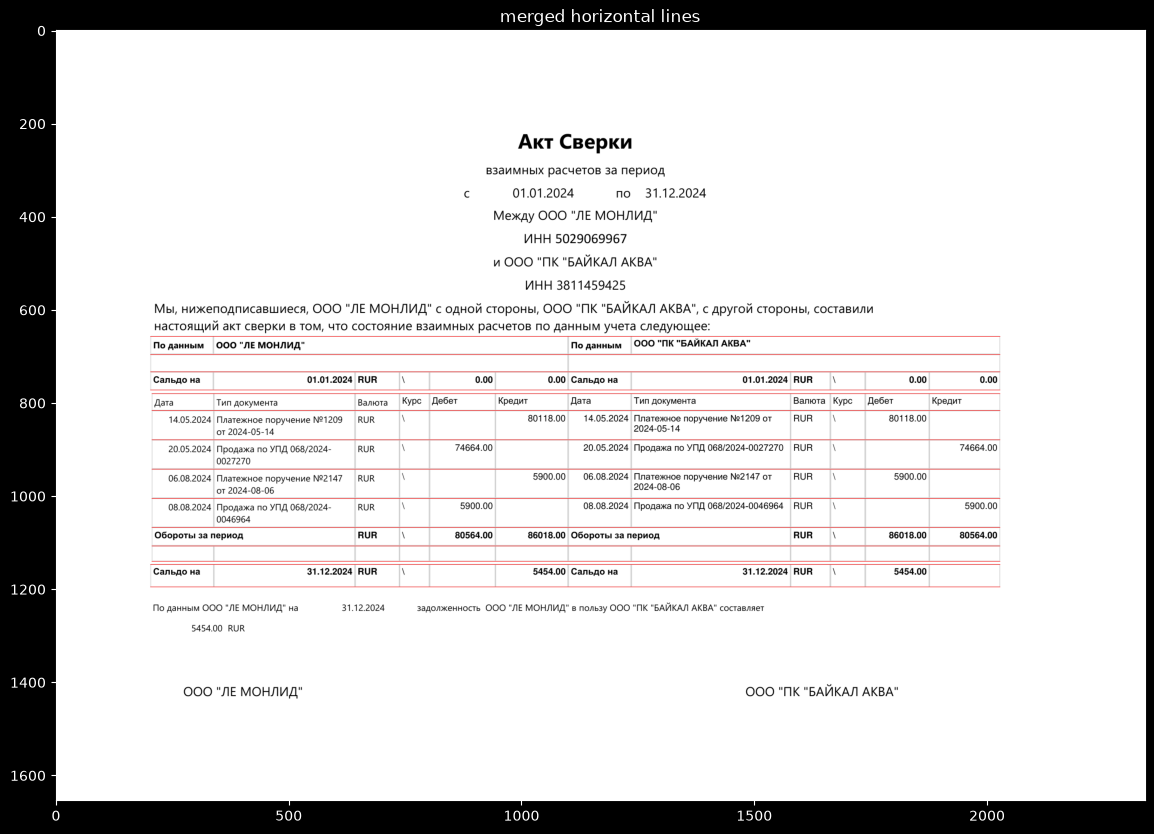

In [17]:
h_lines = [
    extract_lines(
        lines,
        axis=LineAxis.Y,
        axis_tol=5,
        merge_gap=5,
        min_len=10,
    )
    for lines in h_raw_lines
]

h_segments_img = img.copy()
for bbox, box_lines in zip(bboxes, h_lines, strict=False):
    x_min, y_min, x_max, y_max = bbox.to_tuple()
    for y_axis, x_segs in box_lines:
        for x_start, x_end in x_segs:
            cv2.line(
                h_segments_img,
                (x_start + x_min, y_axis + y_min),
                (x_end + x_min, y_axis + y_min),
                (255, 0, 0),
                1,
            )

plt.figure(figsize=(20, 10))
plt.imshow(h_segments_img)
plt.title("merged horizontal lines")
plt.show()

In [18]:
def median_axis_step(
    lines_by_box: list[list[tuple[int, SegmentsArray]]],
    default: int = 0,
) -> list[int]:
    result: list[int] = []
    for box_lines in lines_by_box:
        axes = np.array([axis for axis, _ in box_lines], dtype=np.int32)

        if axes.size < 2:
            result.append(default)
            continue

        axes = np.sort(axes)
        diffs = np.diff(axes)
        diffs = diffs[diffs > 0]

        if diffs.size == 0:
            result.append(default)
            continue

        result.append(int(np.median(diffs)))
    return result
median_dist_rows = median_axis_step(h_lines)
print(f"Median height of horizontal lines: {median_dist_rows}")


Median height of horizontal lines: [48, 62, 39]


Text(0.5, 1.0, 'line mask')

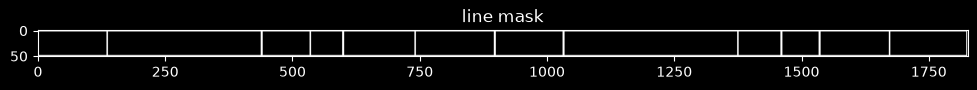

In [19]:
v_lines_mask = []
v_raw_lines = []
for bbox, dist in zip(bboxes, median_dist_rows, strict=False):
    box_bin = bbox.roi(bin_img)
    if dist == 0:
        v_lines_mask.append(np.zeros_like(box_bin))
        v_raw_lines.append(None)
        continue
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, dist))
    mask = cv2.morphologyEx(box_bin, cv2.MORPH_OPEN, vertical_kernel, iterations=1)
    v_lines_mask.append(mask)
    lines = cv2.HoughLinesP(mask, 1, np.pi / 180, 15,
                              minLineLength=dist ,
                              maxLineGap=int(dist * 0.8))
    v_raw_lines.append(lines)


mask = cv2.bitwise_or(h_lines_mask[0], v_lines_mask[0])

plt.figure(figsize=(12, 8))
plt.imshow(mask, cmap='gray')
plt.title('line mask')

Всего вертикальных линий: 13


Text(0.5, 1.0, 'merged vertical lines')

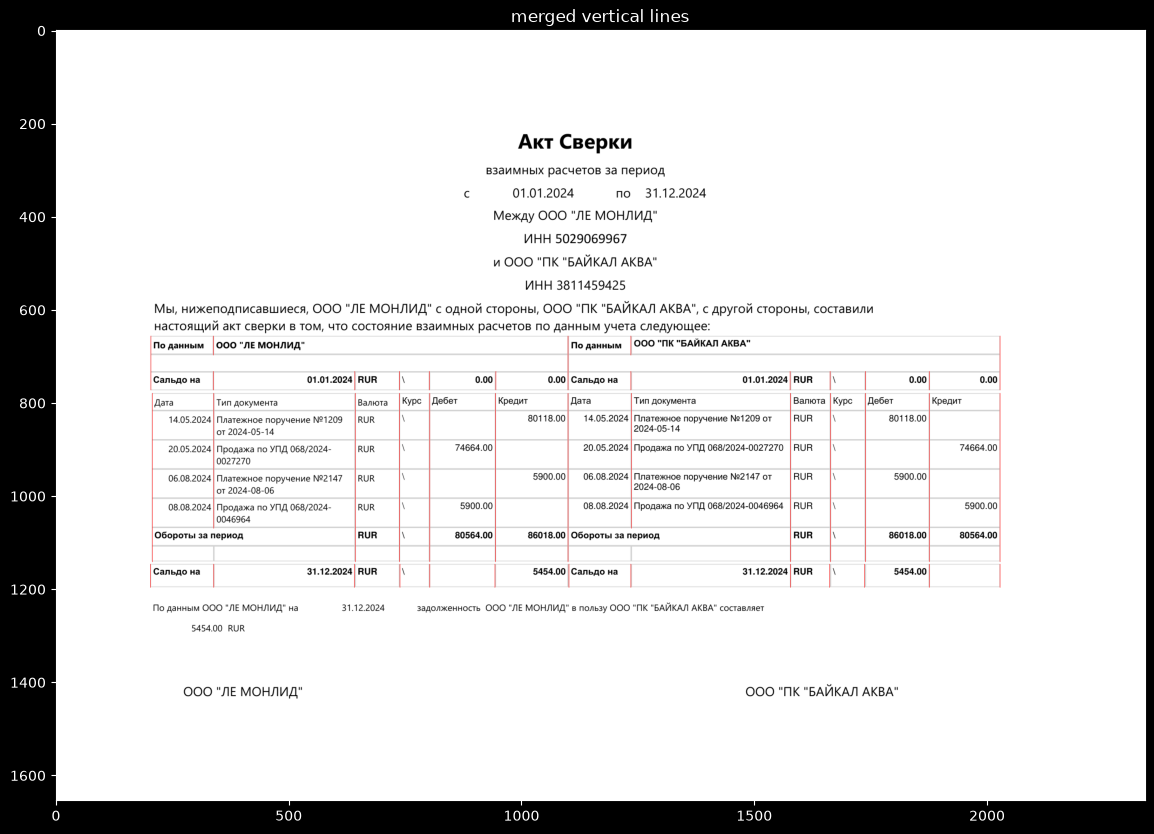

In [20]:
v_lines = [
    extract_lines(
        lines,
        axis=LineAxis.X,
        axis_tol=5,
        merge_gap=5,
        min_len=dist,
    )
    for lines in v_raw_lines
]

v_segments_img = img.copy()

for bbox, box_lines in zip(bboxes, v_lines, strict=False):
    x_min, y_min, x_max, y_max = bbox.to_tuple()
    for x_c, segs in box_lines:
        for y_start, y_end in segs:
            cv2.line(v_segments_img, 
                     (x_c + x_min, y_start + y_min), 
                     (x_c + x_min, y_end + y_min), 
                     (255, 0, 0), 1)

print(f"Всего вертикальных линий: {len(v_lines[0])}")
plt.figure(figsize=(20, 10))
plt.imshow(v_segments_img)
plt.title("merged vertical lines")

In [21]:
median_dist_cols = median_axis_step(v_lines)
print(f"Median width of vertical lines: {median_dist_cols}")

Median width of vertical lines: [137, 136, 136]


Drawing horizontal line at y=1 with segments: [[   0 1825]]
Drawing line from (203, 1147) to (2028, 1147)
Drawing horizontal line at y=49 with segments: [[   0 1825]]
Drawing line from (203, 1195) to (2028, 1195)
Drawing vertical line at x=0 with segments: [[ 0 50]]
Drawing line from (203, 1146) to (203, 1196)
Drawing vertical line at x=136 with segments: [[ 0 50]]
Drawing line from (339, 1146) to (339, 1196)
Drawing vertical line at x=438 with segments: [[ 0 50]]
Drawing line from (641, 1146) to (641, 1196)
Drawing vertical line at x=536 with segments: [[ 0 50]]
Drawing line from (739, 1146) to (739, 1196)
Drawing vertical line at x=600 with segments: [[ 0 50]]
Drawing line from (803, 1146) to (803, 1196)
Drawing vertical line at x=740 with segments: [[ 0 50]]
Drawing line from (943, 1146) to (943, 1196)
Drawing vertical line at x=899 with segments: [[ 0 50]]
Drawing line from (1102, 1146) to (1102, 1196)
Drawing vertical line at x=1032 with segments: [[ 0 50]]
Drawing line from (1235

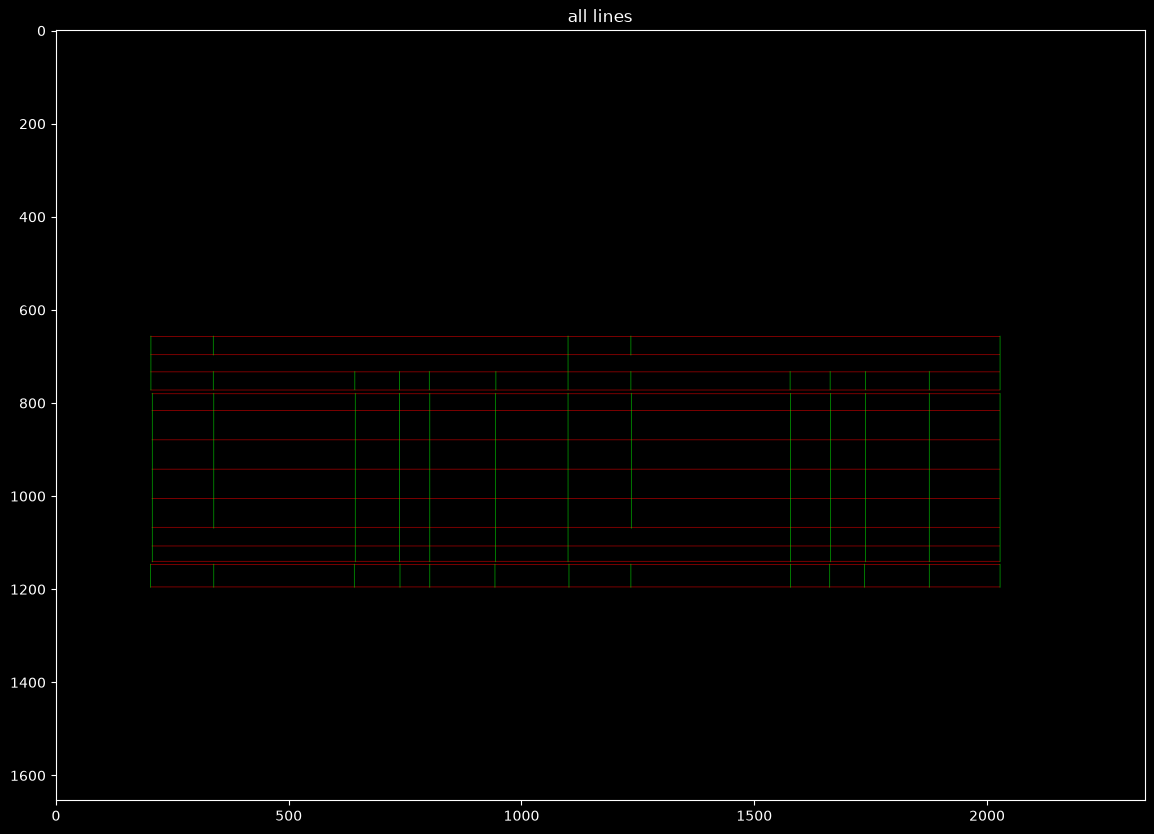

In [22]:
# нарисуем все линии на маске
zero_img = np.zeros_like(img)

for bbox, h_box, v_box in zip(bboxes, h_lines, v_lines, strict=False):
    x, y, x2, y2 = bbox.to_tuple()

    for y_c, segs in h_box:
        print(f"Drawing horizontal line at y={y_c} with segments: {segs}")
        for x_start, x_end in segs:
            print(f"Drawing line from ({x_start + x}, {y_c + y}) to ({x_end + x}, {y_c + y})")
            cv2.line(
                zero_img,
                (x_start + x, y_c + y),
                (x_end + x, y_c + y),
                (255, 0, 0),
                1,
            )

    for x_c, segs in v_box:
        print(f"Drawing vertical line at x={x_c} with segments: {segs}")
        for y_start, y_end in segs:
            print(f"Drawing line from ({x_c + x}, {y_start + y}) to ({x_c + x}, {y_end + y})")
            cv2.line(
                zero_img,
                (x_c + x, y_start + y),
                (x_c + x, y_end + y),
                (0, 255, 0),
                1,
            )
print(f"Total lines drawn: {len(h_lines[0])} horizontal, {len(v_lines[0])} vertical")
plt.figure(figsize=(20, 10))
plt.imshow(zero_img)
plt.title("all lines")
plt.show()

In [23]:
def filter_lines_without_intersections(
    h_lines: list[tuple[int, SegmentsArray]],
    v_lines: list[tuple[int, SegmentsArray]],
    tol: int = 1,
) -> tuple[list[tuple[int, SegmentsArray]], list[tuple[int, SegmentsArray]]]:
    """Убирает линии без пересечений с перпендикулярными."""

    def _covered(value: int, segments: SegmentsArray) -> bool:
        return any(int(s[0]) - tol <= value <= int(s[1]) + tol for s in segments)

    def _has_intersection(axis_val: int, segs: SegmentsArray, others: list[tuple[int, SegmentsArray]]) -> bool:
        # h_line: axis_val=y, segs=x-сегменты; v_line: axis_val=x, segs=y-сегменты
        return any(
            _covered(other_axis, segs) and _covered(axis_val, other_segs)
            for other_axis, other_segs in others
        )

    filtered_h = [line for line in h_lines if _has_intersection(line[0], line[1], v_lines)]
    filtered_v = [line for line in v_lines if _has_intersection(line[0], line[1], h_lines)]
    return filtered_h, filtered_v

filtered_h_lines = []
filtered_v_lines = []
for h_box, v_box in zip(h_lines, v_lines, strict=False):
    fh, fv = filter_lines_without_intersections(h_box, v_box)
    filtered_h_lines.append(fh)
    filtered_v_lines.append(fv)



In [24]:
def axes_to_abs(
    box_lines: list[tuple[int, SegmentsArray]],
    offset: int,
) -> np.ndarray:
    if not box_lines:
        return np.empty(0, dtype=np.int32)

    axes = np.fromiter((axis for axis, _ in box_lines), dtype=np.int32, count=len(box_lines))
    return np.sort(axes + np.int32(offset))

def complete_grid_axes(
    axes_abs: np.ndarray,
    axis_min: int,
    axis_max: int,
    expected_step: int = 0,
) -> np.ndarray:
    axes = np.asarray(axes_abs, dtype=np.int32)
    if axes.size == 0:
        return np.array([axis_min, axis_max], dtype=np.int32)

    axes = np.unique(np.sort(axes))
    tol = max(8, expected_step // 2) if expected_step > 0 else 8

    if axes[0] > axis_min + tol:
        axes = np.r_[np.int32(axis_min), axes]

    if axes[-1] < axis_max - tol:
        axes = np.r_[axes, np.int32(axis_max)]

    if axes.size == 1:
        if abs(int(axes[0]) - axis_min) >= abs(axis_max - int(axes[0])):
            axes = np.r_[np.int32(axis_min), axes]
        else:
            axes = np.r_[axes, np.int32(axis_max)]

    return np.unique(np.sort(axes.astype(np.int32, copy=False)))


def build_grid(
    bbox: BBox,
    h_box: list[tuple[int, SegmentsArray]],
    v_box: list[tuple[int, SegmentsArray]],
) -> tuple[np.ndarray, np.ndarray]:
    x_min, y_min, x_max, y_max = bbox.to_tuple()

    row_ys = complete_grid_axes(
        axes_to_abs(h_box, y_min),
        axis_min=y_min,
        axis_max=y_max,
        expected_step=median_dist_rows[i] // 2,
    )
    col_xs = complete_grid_axes(
        axes_to_abs(v_box, x_min),
        axis_min=x_min,
        axis_max=x_max,
        expected_step=median_dist_cols[i] // 2,
    )

    return row_ys, col_xs

grids = []
for i, (bbox, h_box, v_box) in enumerate(zip(bboxes, filtered_h_lines, filtered_v_lines, strict=False)):
    x_min, y_min, x_max, y_max = bbox.to_tuple()

    row_ys, col_xs = build_grid(bbox, h_box, v_box)

    grids.append((row_ys, col_xs))
    print(f"bbox {i}: {len(row_ys)-1} rows x {len(col_xs)-1} cols")

bbox 0: 1 rows x 12 cols
bbox 1: 7 rows x 12 cols
bbox 2: 3 rows x 12 cols


bbox 0: 1 rows x 12 cols
bbox 1: 7 rows x 12 cols
bbox 2: 3 rows x 12 cols


Text(0.5, 1.0, 'final grid')

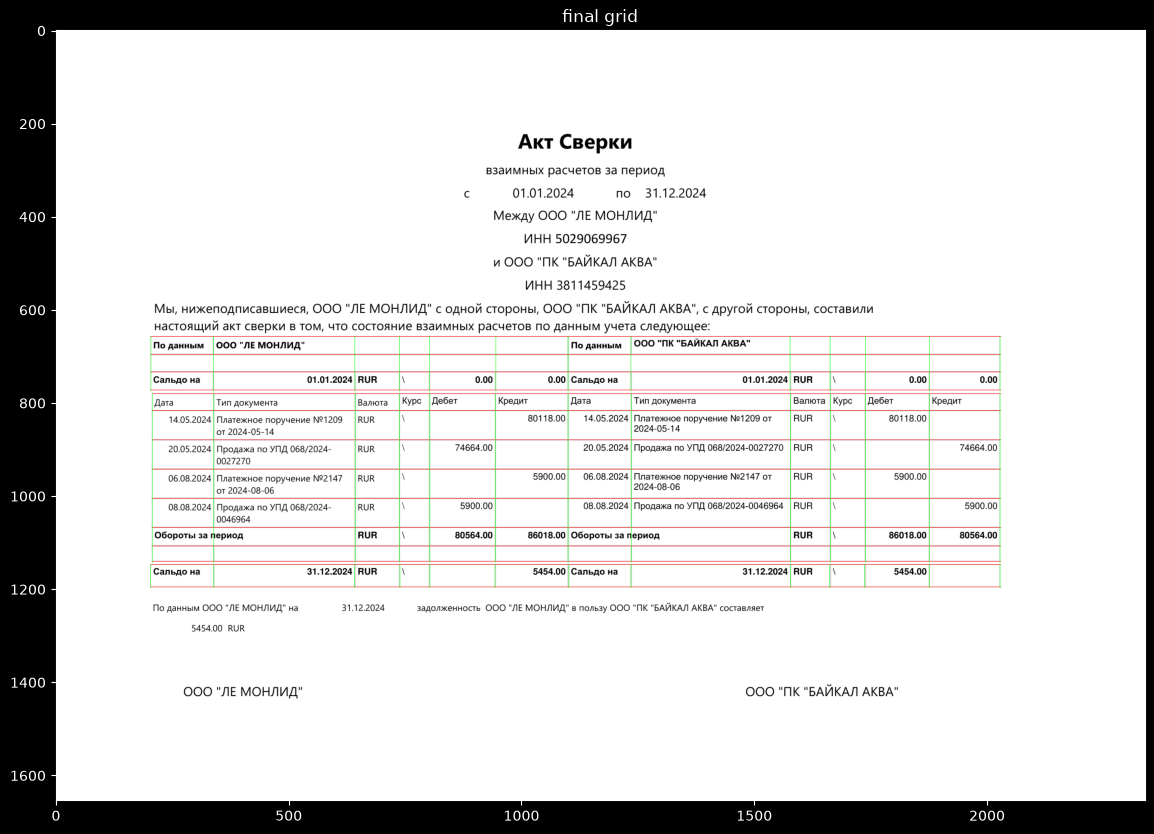

In [25]:

grid_img = img.copy()

for i, (row_ys, col_xs) in enumerate(grids):
    print(f"bbox {i}: {len(row_ys)-1} rows x {len(col_xs)-1} cols")
    x_min, y_min, x_max, y_max = bboxes[i].to_tuple()
    for y in row_ys:
        cv2.line(grid_img, (x_min, y), (x_max, y), (255, 0, 0), 1)
    for x in col_xs:
        cv2.line(grid_img, (x, y_min), (x, y_max), (0, 255, 0), 1)

plt.figure(figsize=(20, 10))
plt.imshow(grid_img)
plt.title("final grid")

In [26]:
import uuid
from enum import Enum

import numpy as np

from vision_core.entities.bbox import BBox
from vision_core.entities.cell import Cell
from vision_core.entities.table import Table


class MergeMode(Enum):
    NONE = "none"
    ALL = "all"
    ROWS = "rows"
    COLS = "cols"


def has_h_sep(h_lines_box, rel_y, x1, x2, tol=8, min_cov=0.5):
    for y_c, segs in h_lines_box:
        if abs(y_c - rel_y) <= tol:
            length = x2 - x1
            covered = sum(max(0, min(xe, x2) - max(xs, x1)) for xs, xe in segs)
            if length > 0 and covered / length >= min_cov:
                return True
    return False


def has_v_sep(v_lines_box, rel_x, y1, y2, tol=8, min_cov=0.5):
    for x_c, segs in v_lines_box:
        if abs(x_c - rel_x) <= tol:
            length = y2 - y1
            covered = sum(max(0, min(ye, y2) - max(ys, y1)) for ys, ye in segs)
            if length > 0 and covered / length >= min_cov:
                return True
    return False


def build_separators(bbox, row_ys, col_xs, h_lines_box, v_lines_box):
    x_min, y_min, _, _ = bbox.to_tuple()
    n_rows = len(row_ys) - 1
    n_cols = len(col_xs) - 1

    h_sep = np.zeros((max(n_rows - 1, 0), max(n_cols, 0)), dtype=bool)
    for i in range(n_rows - 1):
        rel_y = row_ys[i + 1] - y_min
        for j in range(n_cols):
            h_sep[i, j] = has_h_sep(
                h_lines_box,
                rel_y,
                col_xs[j] - x_min,
                col_xs[j + 1] - x_min,
            )

    v_sep = np.zeros((max(n_rows, 0), max(n_cols - 1, 0)), dtype=bool)
    for j in range(n_cols - 1):
        rel_x = col_xs[j + 1] - x_min
        for i in range(n_rows):
            v_sep[i, j] = has_v_sep(
                v_lines_box,
                rel_x,
                row_ys[i] - y_min,
                row_ys[i + 1] - y_min,
            )

    return h_sep, v_sep


def collect_union_pairs(n_rows, n_cols, h_sep, v_sep, mode: MergeMode):
    if mode is MergeMode.NONE or n_rows <= 0 or n_cols <= 0:
        return np.empty((0, 2), dtype=np.int32)

    pairs = []

    if mode in (MergeMode.ALL, MergeMode.COLS) and n_cols > 1:
        r, c = np.where(~v_sep)
        left = r * n_cols + c
        right = left + 1
        if left.size:
            pairs.append(np.column_stack((left, right)).astype(np.int32, copy=False))

    if mode in (MergeMode.ALL, MergeMode.ROWS) and n_rows > 1:
        r, c = np.where(~h_sep)
        top = r * n_cols + c
        bottom = top + n_cols
        if top.size:
            pairs.append(np.column_stack((top, bottom)).astype(np.int32, copy=False))

    if not pairs:
        return np.empty((0, 2), dtype=np.int32)

    return np.vstack(pairs).astype(np.int32, copy=False)


def dsu_build(size: int, pairs: np.ndarray) -> np.ndarray:
    parent = np.arange(size, dtype=np.int32)
    rank = np.zeros(size, dtype=np.int8)

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    for a, b in pairs:
        union(int(a), int(b))

    for i in range(size):
        parent[i] = find(i)

    return parent


def build_table(
    bbox: BBox,
    row_ys: np.ndarray,
    col_xs: np.ndarray,
    h_lines_box,
    v_lines_box,
    merge_mode: MergeMode = MergeMode.ALL,
) -> Table:
    x_min, y_min, x_max, y_max = bbox.to_tuple()
    n_rows = len(row_ys) - 1
    n_cols = len(col_xs) - 1
    total = n_rows * n_cols

    if total <= 0:
        return Table(
            id=str(uuid.uuid4()),
            bbox=BBox(x_min=x_min, y_min=y_min, x_max=x_max, y_max=y_max),
            num_rows=max(n_rows, 0),
            num_cols=max(n_cols, 0),
            cells=[],
        )

    h_sep, v_sep = build_separators(bbox, row_ys, col_xs, h_lines_box, v_lines_box)
    pairs = collect_union_pairs(n_rows, n_cols, h_sep, v_sep, merge_mode)
    parent = dsu_build(total, pairs)

    groups = {}
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            groups.setdefault(int(parent[idx]), []).append((i, j))

    cells = []
    for indices in groups.values():
        rows = [i for i, _ in indices]
        cols = [j for _, j in indices]
        r0, r1 = min(rows), max(rows) + 1
        c0, c1 = min(cols), max(cols) + 1
        cells.append(
            Cell(
                row=r0,
                col=c0,
                rowspan=r1 - r0,
                colspan=c1 - c0,
                bbox=BBox(
                    x_min=int(col_xs[c0]),
                    y_min=int(row_ys[r0]),
                    x_max=int(col_xs[c1]),
                    y_max=int(row_ys[r1]),
                ),
            )
        )

    return Table(
        id=str(uuid.uuid4()),
        bbox=BBox(x_min=x_min, y_min=y_min, x_max=x_max, y_max=y_max),
        num_rows=n_rows,
        num_cols=n_cols,
        cells=cells,
    )


tables_by_mode = {
    MergeMode.NONE: [],
    MergeMode.ALL: [],
    MergeMode.ROWS: [],
    MergeMode.COLS: [],
}

for bbox, (row_ys, col_xs), box_h, box_v in zip(bboxes, grids, h_lines, v_lines, strict=False):
    for mode in tables_by_mode:
        tables_by_mode[mode].append(
            build_table(
                bbox=bbox,
                row_ys=row_ys,
                col_xs=col_xs,
                h_lines_box=box_h,
                v_lines_box=box_v,
                merge_mode=mode,
            )
        )

tables_none = tables_by_mode[MergeMode.NONE]
tables_all = tables_by_mode[MergeMode.ALL]
tables_rows = tables_by_mode[MergeMode.ROWS]
tables_cols = tables_by_mode[MergeMode.COLS]

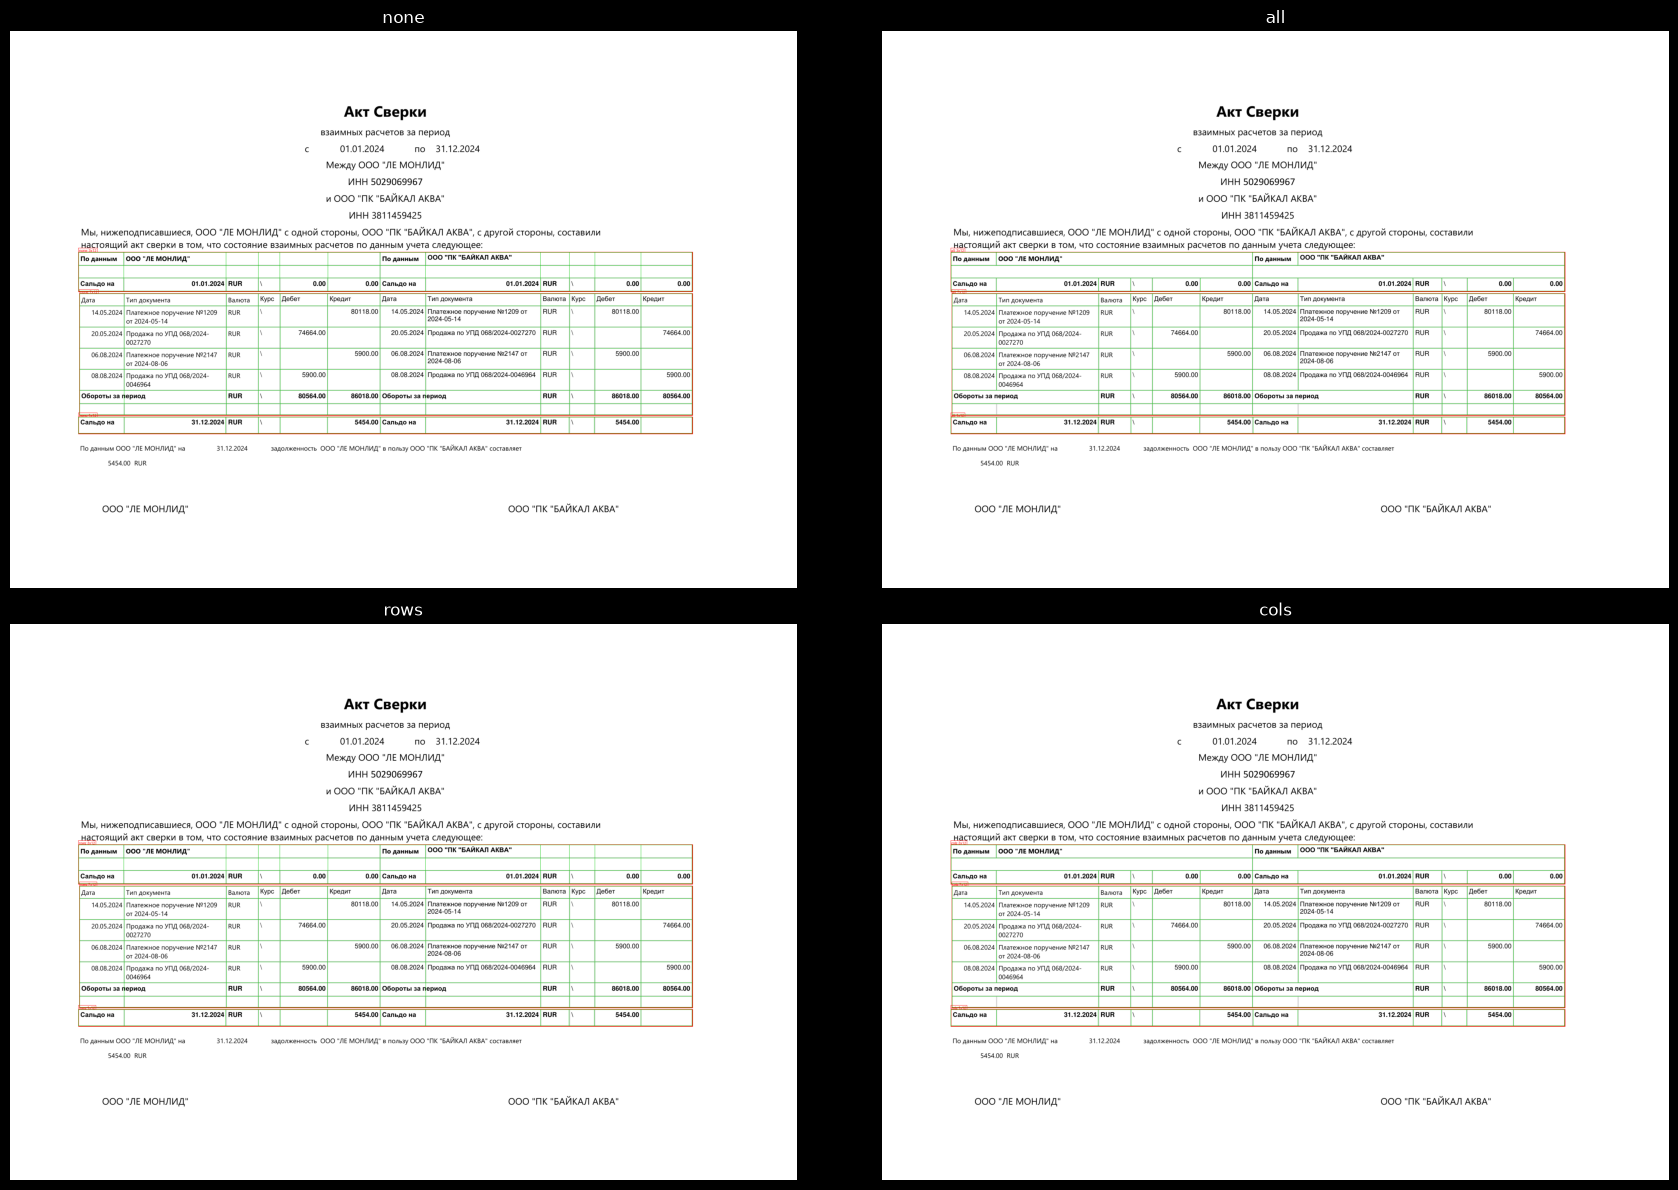

In [27]:
import matplotlib.pyplot as plt

from vision_core.utils.drawer import Drawer

mode_order = [MergeMode.NONE, MergeMode.ALL, MergeMode.ROWS, MergeMode.COLS]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, mode in zip(axes.ravel(), mode_order, strict=False):
    drawer = Drawer(img.copy(), side_by_side=False)

    for table in tables_by_mode[mode]:
        drawer.draw_table_structure(
            table_bbox_xyxy=table.bbox.to_tuple(),
            cells=table.cells,
            label=f"{mode.value}: {table.num_rows}x{table.num_cols}",
            color=(255, 0, 0),
            cell_color=(0, 200, 0),
            text_color=(0, 0, 0),
        )

    ax.imshow(drawer.to_numpy())
    ax.set_title(mode.value)
    ax.axis("off")

plt.tight_layout()
plt.show()

